<div style="text-align: center; padding: 30px 10px;">

<h1 style="color:#ff7500; font-size: 24px; margin-bottom: 10px;">
МФТИ ФПМИ
</h1>

<h2 style="font-size: 30px; margin-top: 5px;">
Практикум Python - Продвинутый Поток
</h2>

<hr style="width: 60%; border: 1px solid #10069f; margin: 25px auto;">

<h3 style="font-size: 36px;">
Лекция 1. Namespaces. Scopes. LEGB-rule. Замыкания. Декораторы.
</h3>

<p style="margin-top: 20px;">
<strong>Дата:</strong> 28 февраля 2026 года<br>
</p>

<p style="margin-top: 25px;">
Данный ноутбук является частью серии семинаров по курсу  
<em>«Практикум Python»</em> и предназначен для учебных и образовательных целей.
</p>

</div>

# Напоминание

В прошлых сериях (лекции) мы обсуждали объекты и работу с ними

In [ ]:
class Example:
    a = 5
    b = "abc"

    def __init__(self, c):
        self.c = c

    def foo(self):
        print(self.c)

e = Example(5)
print(Example.__dict__)
print(vars(Example))
print()
print(e.__dict__)
print(vars(e))

{'__module__': '__main__', 'a': 5, 'b': 'abc', '__init__': <function Example.__init__ at 0x7f007c112160>, 'foo': <function Example.foo at 0x7f007c112200>, '__dict__': <attribute '__dict__' of 'Example' objects>, '__weakref__': <attribute '__weakref__' of 'Example' objects>, '__doc__': None}
{'__module__': '__main__', 'a': 5, 'b': 'abc', '__init__': <function Example.__init__ at 0x7f007c112160>, 'foo': <function Example.foo at 0x7f007c112200>, '__dict__': <attribute '__dict__' of 'Example' objects>, '__weakref__': <attribute '__weakref__' of 'Example' objects>, '__doc__': None}

{'c': 5}
{'c': 5}


И обсуждали датаклассы

In [ ]:
# Вариант 1.

garden = [(0, 10, 20), (1, 10, 20), (2, 20, 10)]

for t in garden:
    print(f"{t[0]} tomato is {t[1]} days old. It will be ready for harvesting in {t[2]} days")

0 tomato is 10 days old. It will be ready for harvesting in 20 days
1 tomato is 10 days old. It will be ready for harvesting in 20 days
2 tomato is 20 days old. It will be ready for harvesting in 10 days


In [ ]:
# Вариант 2.

from dataclasses import dataclass

@dataclass(order=True)
class Tomato:
    num: int
    days_old: int
    days_till_harvest: int

garden = [Tomato(0, 10, 20), Tomato(0, 10, 20), Tomato(1, 20, 10)]

for i in range(len(garden)):
    print(garden[i].__repr__())

print(garden[0] < garden[2])

Tomato(num=0, days_old=10, days_till_harvest=20)
Tomato(num=0, days_old=10, days_till_harvest=20)
Tomato(num=1, days_old=20, days_till_harvest=10)
True


# `__slots__`

Это атрибут класса, который заменяет собой `__dict__` и таким образом фиксирует атрибуты у объекта.

Это призвано ускорить работу программы и снизить использование паамяти.

In [ ]:
class A:
    __slots__ = ('x', 'y')

a = A()
a.__dict__

AttributeError: 'A' object has no attribute '__dict__'

In [ ]:
a.x = 5
a.y = 7
print(a.x)
print(a.y)
a.z = 10

5
7


AttributeError: 'A' object has no attribute 'z'

Зачем это нужно?

In [ ]:
import sys
import time

In [ ]:
class A:
    def __init__(self, x, y):
        self.x = x
        self.y = y

l = []

strt = time.time()

for i in range(1000):
    for j in range(1000):
        l.append(A(i, j))

end = time.time()

print(sys.getsizeof(l))
print(sys.getsizeof(l[0]))
print(sys.getsizeof(A))
print(end - strt)

8448728
48
1704
1.168416976928711


In [ ]:
class B:
    __slots__ = ('x', 'y')

    def __init__(self, x, y):
        self.x = x
        self.y = y

l = []

strt = time.time()

for i in range(1000):
    for j in range(1000):
        l.append(B(i, j))

end = time.time()

print(sys.getsizeof(l))
print(sys.getsizeof(l[0]))
print(sys.getsizeof(B))
print(end - strt)

8448728
48
936
1.0144340991973877


Почему так?




Просто sys.getsizeof() не рекурсивен :)

In [ ]:
!pip install memory_profiler

In [ ]:
from memory_profiler import memory_usage
import statistics
import timeit


class PointNoSlots:
    def __init__(self, x, y):
        self.x = x
        self.y = y



class PointSlots:
    __slots__ = ('x', 'y')

    def __init__(self, x, y):
        self.x = x
        self.y = y



def wrp(cls):
    def cp():
        return [cls(i, i) for i in range(1000000)]
    return cp



if __name__ == "__main__":
    mem_v = []
    mem_t = []

    for cls in [PointNoSlots, PointSlots]:
        print(cls.__name__)
        for _ in range(10):
            mem_v.append(max(memory_usage(wrp(cls), interval=0.01)))

            pnt = cls(5, 2)
            mem_t.append(timeit.timeit(lambda: (pnt.x, pnt.y), number=1000000))

        print(statistics.mean(mem_v))
        print(statistics.mean(mem_t))


PointNoSlots
370.95625
0.08780510540009345
PointSlots
355.6517578125
0.0791906175999884


Локально у меня был такой результат:

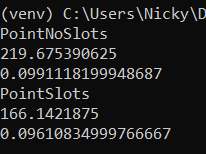

# Namespace

Из [Zen of Python](https://peps.python.org/pep-0020/):

> Namespaces are one honking great idea -- let's do more of those!

A namespace is a mapping from names to objects.

Неймспейс - это некое соотношение названий и объектов.

## Пример Namespace 1. Классы.

In [ ]:
class N:
    pass

n = N()

n.a = 5
print(n.a)


setattr(n, "b", "python")
print(getattr(n, "b"))

delattr(n, "a")
print(n.a)

5
python


AttributeError: 'N' object has no attribute 'a'

Стоит заметить, что помимо неймспейса (`__dict__` или `__slots__`) у классов и объектов есть бОльшее число функциональности помимо соотношения название и объект (например, MRO и наследование). Однако в основе лежит некий неймспейс.

## 2. Пример Namespace 2. `types.SimpleNamespace`

In [ ]:
from types import SimpleNamespace

n = SimpleNamespace()

n.a = 5
print(n.a)
print(n)

setattr(n, "b", "python")
print(getattr(n, "b"))

delattr(n, "a")
print(n.a)

5
namespace(a=5)
python


AttributeError: 'types.SimpleNamespace' object has no attribute 'a'

Всё то же самое, что выше - просто так чище, так как создание класса только для использования как неймспейса - моветон. Плюс SimpleNamespace переопределяет `__repr__` и `__eq__`, что большой плюс.

## Пример Namespace 3. Функции

Поподробнее про них будет позже, однако, глобально можно считать, что функция состоит из некоторого неймспейса, байткода и некой метаинформации о ней

In [ ]:
import dis

In [ ]:
def wrap():
    a = 10

    def foo(x = []):
        """Это какая-то функция."""
        print(a)

    return foo


f = wrap()
# Метаинформация
print(f.__name__) # название
print(f.__module__) # модуль
print(f.__doc__) #
print()

# Байткод
print(dis.dis(f))
print()

# Неймспейс
print(f.__closure__)
print("Содержание неймспейса:")
for el in f.__closure__:
    print(el.cell_contents)

foo
__main__
Это какая-то функция.

              0 COPY_FREE_VARS           1

  4           2 RESUME                   0

  6           4 LOAD_GLOBAL              1 (NULL + print)
             14 LOAD_DEREF               0 (a)
             16 CALL                     1
             24 POP_TOP
             26 RETURN_CONST             1 (None)
None

(<cell at 0x7f005418f160: int object at 0xb1a608>,)
Содержание неймспейса:
10


## Пример Namespace 4. Модули

> A module is a file containing Python definitions and statements. The file name is the module name with the suffix .py appended.

[6. Modules - Python documentation](https://docs.python.org/3/tutorial/modules.html)

Да, даже сами модули по своей сути Namespace'ы. При этом они ближе всего к неймспейсу - отвечают только за обращение к объектам.

Пусть файл a.py выглядит так:



```
def foo():
    print(5)

def foo2():
    print(__name__)
```



In [ ]:
import a

a.foo()

5


In [ ]:
a.foo2()

a


In [ ]:
__name__

'__main__'

Более того! Я могу применять функции `getattr`, `setattr` и `delattr` к модулям!!

In [ ]:
setattr(a, "a", 10)
print(a.a)
print(getattr(a, "a"))
print()

delattr(a, "a")
print(a.a)

10
10



AttributeError: module 'a' has no attribute 'a'

In [ ]:
print(getattr(a, "foo"))

<function foo at 0x7f007caebd80>


## Пример Namespace 5. Пространство переменных.

In [ ]:
globals()

{'__name__': '__main__',
 '__doc__': 'Automatically created module for IPython interactive environment',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'class Example:\n    a = 5\n    b = "abc"\n\n    def __init__(self, c):\n        self.c = c\n    \n    def foo(self):\n        print(self.c)\n\ne = Example(5)\nprint(Example.__dict__)\nprint(vars(Example))\nprint()\nprint(e.__dict__)\nprint(vars(e))',
  '# Вариант 1.\n\ngarden = [(0, 10, 20), (1, 10, 20), (2, 20, 10)]\n\nfor t in garden:\n    print(f"{t[0]} tomato is {t[1]} days old. It will be ready for harvesting in {t[2]} days")',
  '# Вариант 2.\n\nfrom dataclasses import dataclass\n\n@dataclass(order=True)\nclass Tomato:\n    num: int\n    days_old: int\n    days_till_harvest: int\n\ngarden = [Tomato(0, 10, 20), Tomato(0, 10, 20), Tomato(1, 20, 10)]\n\nfor i in range(len(garden)):\n    print(garden[i].__rep

## Пример Namespace 6. `__builtins__`

In [ ]:
dir(__builtins__)

['ArithmeticError',
 'AssertionError',
 'AttributeError',
 'BaseException',
 'BaseExceptionGroup',
 'BlockingIOError',
 'BrokenPipeError',
 'BufferError',
 'BytesWarning',
 'ChildProcessError',
 'ConnectionAbortedError',
 'ConnectionError',
 'ConnectionRefusedError',
 'ConnectionResetError',
 'DeprecationWarning',
 'EOFError',
 'Ellipsis',
 'EncodingWarning',
 'EnvironmentError',
 'Exception',
 'ExceptionGroup',
 'False',
 'FileExistsError',
 'FileNotFoundError',
 'FloatingPointError',
 'FutureWarning',
 'GeneratorExit',
 'IOError',
 'ImportError',
 'ImportWarning',
 'IndentationError',
 'IndexError',
 'InterruptedError',
 'IsADirectoryError',
 'KeyError',
 'KeyboardInterrupt',
 'LookupError',
 'MemoryError',
 'ModuleNotFoundError',
 'NameError',
 'None',
 'NotADirectoryError',
 'NotImplemented',
 'NotImplementedError',
 'OSError',
 'OverflowError',
 'PendingDeprecationWarning',
 'PermissionError',
 'ProcessLookupError',
 'RecursionError',
 'ReferenceError',
 'ResourceWarning',
 'Runti

**Умная мысль:** всё в Python объект. Объекты тесно связаны с Namespace'ами, поэтому неймспейсы тоже почти везде.

# Работа с модулями

Способы импортировать модуль:

`import module_A, module_B`

`import module_A as a`

Если мы хотим имортироать в текущий неймспейс, а не создавать новый, можно использовать:

`from module_A import foo`

`from module_A import foo as f`

`from module_A import *`

In [ ]:
%%file mod_0.py
print("Mod_0 started!")

a = "abc"

def foo():
    print("foo")

print("Mod_0 ended!")

Overwriting mod_0.py


In [ ]:
import mod_0 as m0

print(m0.a)

Mod_0 started!
Mod_0 ended!
abc


In [ ]:
%%file mod_1.py
print("Mod_1 started!")

a = "abc"

def foo():
    print("foo")

print("Mod_1 ended!")

Writing mod_1.py


In [ ]:
from mod_1 import foo as f

f()

foo


In [ ]:
import mod_0 as mm0

Почему не вывело ещё раз про начало и конец?

In [ ]:
print(sys.modules)

{'sys': <module 'sys' (built-in)>, 'builtins': <module 'builtins' (built-in)>, '_frozen_importlib': <module '_frozen_importlib' (frozen)>, '_imp': <module '_imp' (built-in)>, '_thread': <module '_thread' (built-in)>, '_warnings': <module '_warnings' (built-in)>, '_weakref': <module '_weakref' (built-in)>, '_io': <module '_io' (built-in)>, 'marshal': <module 'marshal' (built-in)>, 'posix': <module 'posix' (built-in)>, '_frozen_importlib_external': <module '_frozen_importlib_external' (frozen)>, 'time': <module 'time' (built-in)>, 'zipimport': <module 'zipimport' (frozen)>, '_codecs': <module '_codecs' (built-in)>, 'codecs': <module 'codecs' (frozen)>, 'encodings.aliases': <module 'encodings.aliases' from '/usr/lib/python3.12/encodings/aliases.py'>, 'encodings': <module 'encodings' from '/usr/lib/python3.12/encodings/__init__.py'>, 'encodings.utf_8': <module 'encodings.utf_8' from '/usr/lib/python3.12/encodings/utf_8.py'>, '_signal': <module '_signal' (built-in)>, '_abc': <module '_abc' 

Алгоритм загрузки:

1. Если есть в `sys.modules` - используем уже загруженный модуль
2. Если нет - ищем по `sys.path` (там  в т.ч. текущая директория).
3. Если модуль не найден - `ModuleNotFoundError`
4. Если модуль нашёлся и он написан на Python, то модуль будет собран в байткод и сохранён в папке `__pycache__` с расширением .pyc и соотвесттвующим названием для переиспользования в будущем.

Чтобы собрать байткод модуля, нужно выполнить весь код построчно - поэтому и запускаются print'ы.

## Module reloading

Обычно в модулях мы работаем с классами и функциями, поэтому нам достаточно того, что модуль запускается только 1 раз. Однако иногда нужно обновить его (модуль) не останавливая прогрмму. Для этого есть [importlib.reload](https://docs.python.org/3/library/importlib.html#importlib.reload) - но у него есть свои нюансы с зависимостями модулей.

## Сравнение с классами

In [ ]:
class A:
    print("hi!")

    def foo(self):
        print("middle")

    print("bye!")

a = A()
a.foo()

hi!
bye!
middle


## `__name__`

При этом у каждого модуля есть атрибут `__name__`, который заполнен "__main__", если этот файл сейчас исполняется, и названием модуля, если этот модуль был импортирован.

In [71]:
%%file mod_leak.py

def foo():
    print(__name__)

Writing mod_leak.py


In [72]:
import mod_leak as ml

ml.foo()

mod_leak


## Codestyle

* Все импорты в начале модуля
* Сначала `import`, потом `from ... import`
* Отсортированы в лексикографическом порядке
* Разбиты на 3 группы:
  - Импорты модулей стандартной библиотеки
  - Импорты сторонних библиотек
  - Собственные импорты

Где описано
* https://www.python.org/dev/peps/pep-0008/#imports
* https://google.github.io/styleguide/pyguide.html#s2.2-imports

## Работа с circular imports

In [ ]:
%%file mod_a1.py
from mod_b1 import foo_b

def foo_a():
    pass

Writing mod_a1.py


In [ ]:
%%file mod_b1.py
from mod_a1 import foo_a
def foo_b():
    foo_a()

Writing mod_b1.py


In [70]:
import mod_a1

ImportError: cannot import name 'foo_a' from partially initialized module 'mod_a1' (most likely due to a circular import) (/content/mod_a1.py)

**Что делать?**

1. Задуматься, как мы к этому пришли - возможно, надо просто объединить модули

2. Если не объединяем, то можно добавить импорт внутрь функции foo_a (и мы забиваем на кодстайл)

# Зачем нужны неймспейсы?

**Ответ:** они добавляют инкапсуляцию. Так модули можно импортировать и случайно не затереть уже существующие переменные значениями из модуля.

## Пример 1. `Builtins`

Оказывается, builtins просто модуль. Проверим это:

In [ ]:
__builtins__

<module 'builtins' (built-in)>

Тогда мы можем выкинуть такой трюк:

In [ ]:
import builtins as bltns

len = 5
print(len)
print(bltns.len)

5
<built-in function len>


## Пример 2. Итератор

Рассмотрим пример с семинара

In [ ]:
from re import S
from enum import Enum

class FarmException(Exception):
    pass


class InvalidYieldError(FarmException):
    pass



class CropStatus(Enum):
    """Enum representing the possible statuses of a crop"""
    SEEDLING = "seedling"
    GROWING = "growing"
    READY_FOR_HARVEST = "ready_for_harvest"
    HARVESTED = "harvested"
    WILTED = "wilted"
    DISEASED = "diseased"

class Crop:
    def __init__(self, name: str, crop_yield: int, status: CropStatus = CropStatus.SEEDLING):
        self.name = name
        self.crop_yield = crop_yield  # Using crop_yield instead of yield
        self.status = status

    @property
    def crop_yield(self):
        return self.__crop_yield

    @crop_yield.setter
    def crop_yield(self, x):
        if x < 0:
            raise InvalidYieldError("Oh no! Negative yield :(((((")
        self.__crop_yield = x


class CropHarvester():
    def __init__(self, a):
        self.crops = a.copy()

    def __len__(self):
        return len(self.crops)

    def __iter__(self):
        # мы будем итерироваться по всем, кто готов к сбору
        class HarvestIterator:
            def __init__(s):
                s.index = 0

            def __iter__(s):
                return s

            def __next__(s):
                while s.index < len(self.crops):
                    crop = self.crops[s.index]
                    s.index += 1
                    if crop.status == CropStatus.READY_FOR_HARVEST:
                        return crop
                raise StopIteration

        return HarvestIterator()


In [ ]:
wheat = Crop("wheat", 8, CropStatus.READY_FOR_HARVEST)
corn = Crop("corn", 12, CropStatus.GROWING)
tomato = Crop("tomato", 6, CropStatus.READY_FOR_HARVEST)
potato = Crop("potato", 15, CropStatus.HARVESTED)
carrot = Crop("carrot", 9, CropStatus.SEEDLING)
pumpkin = Crop("pumpkin", 20, CropStatus.READY_FOR_HARVEST)

all_crops = [wheat, corn, tomato, potato, carrot, pumpkin]

ch = CropHarvester(all_crops)
for el in ch:
    print(el.name)

wheat
tomato
pumpkin


Какие плюсы у такой реализации?

1. `HarvestIterator` знает обо всех атрибутах класса-родителя - ему не нужно передавать в init ничего.

2. `HarvestIterator` логично сложен в единственное место, где он будет использован, и его случайно нельзя дёрнуть. Таким образом обеспечивается инкапсуляция и мы не засоряем `globals`. Да и код выглядит чище :)


Минусы:

Мы каждый раз пересоздаём `HarvestIterator` как класс при вызове `CropHarvester.__iter__()`

# Скоупы (Scopes)

> A scope is a textual region of a Python program where a namespace is directly accessible.

[Python documentation](https://docs.python.org/3/tutorial/classes.html)


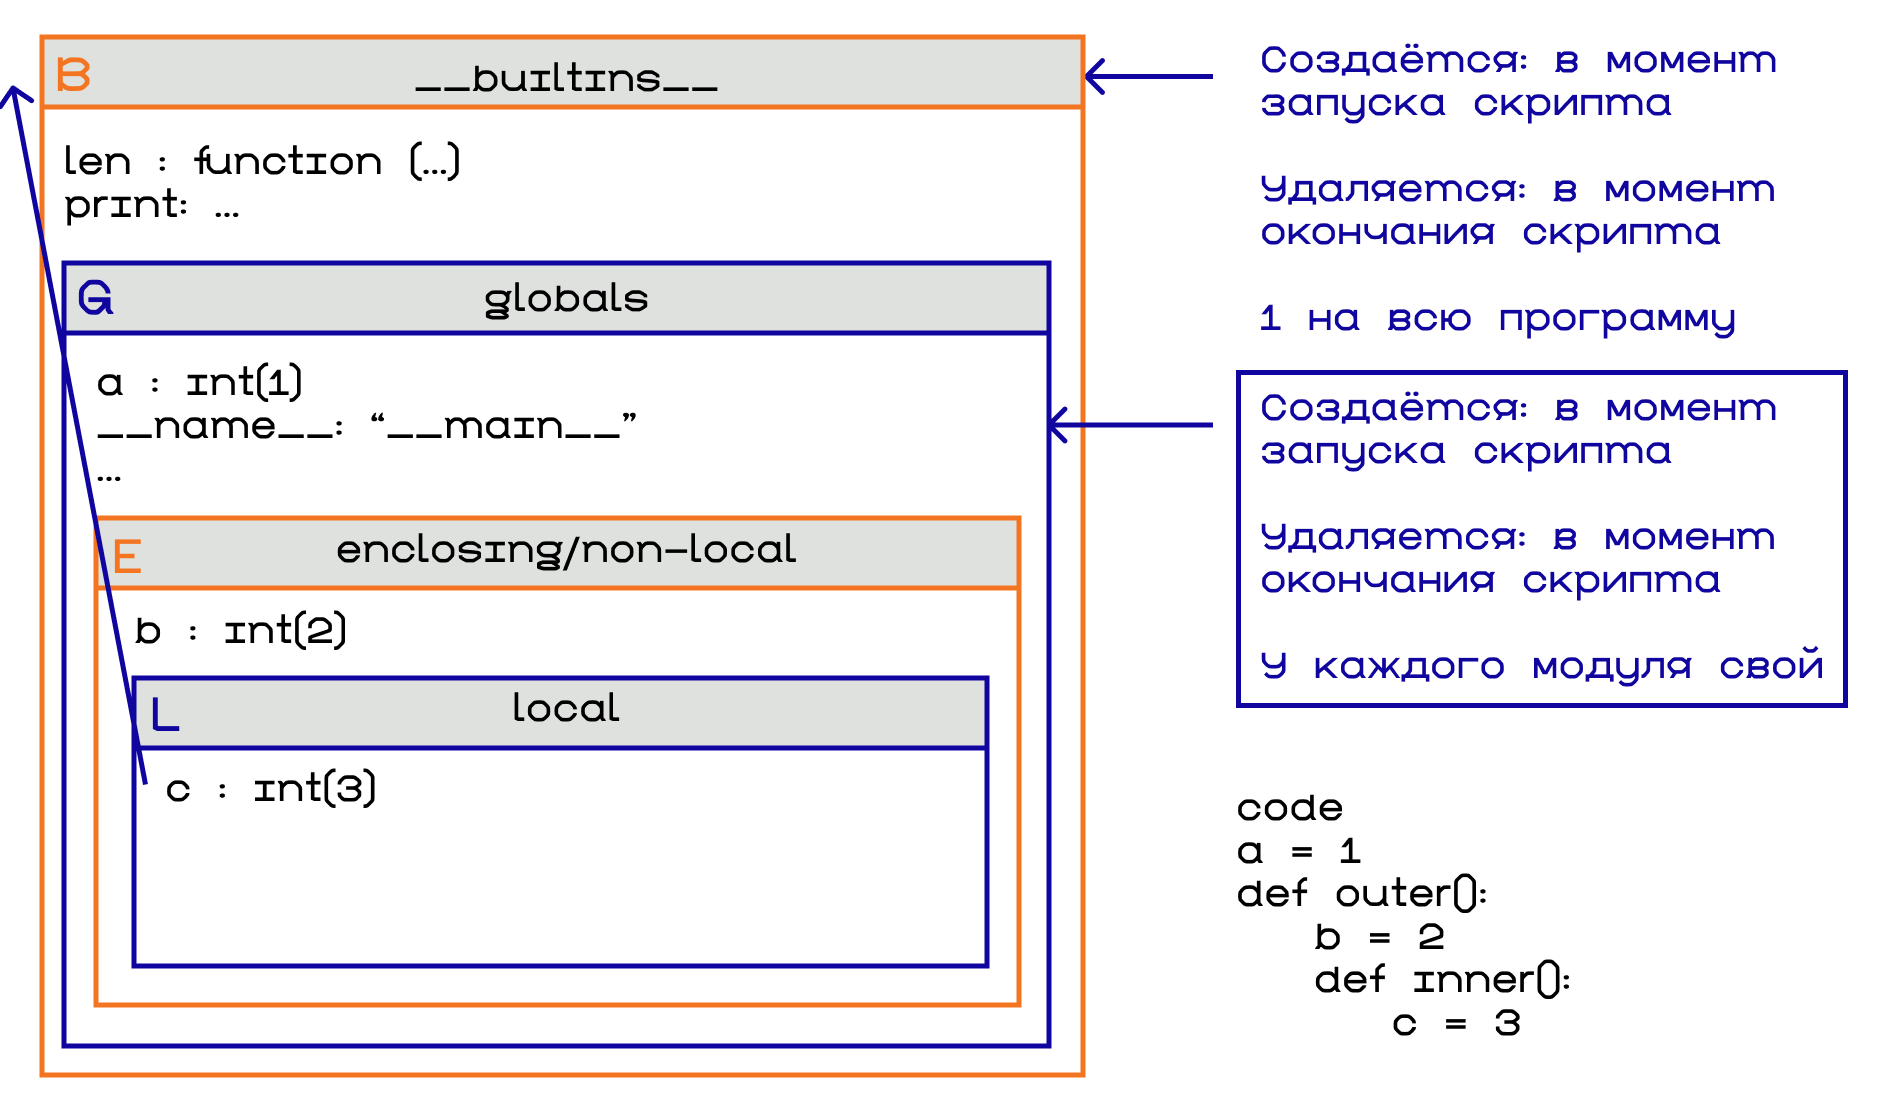

In [1]:
x = 1

def foo():
    y = 12
    print(f'x is {x}')
    print(f'y is {y}')

foo()

x is 1
y is 12


In [2]:
x = 1

def foo():
    x = 2
    y = 12
    print(f'x is {x}')
    print(f'y is {y}')

foo()
print(x)

x is 2
y is 12
1


In [3]:
x = 5

def foo():
    print(f'x is {x}')
    x = 10
    print(f'x is {x}')

foo()

UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

In [4]:
x = 5

def foo():
    print(f'x is {x}')
    global x
    x = 10
    print(f'x is {x}')

foo()

SyntaxError: name 'x' is used prior to global declaration (ipython-input-2635177857.py, line 5)

In [5]:
x = 5

def foo():
    x = 7
    print(f'x is {x}')
    global x
    x = 10
    print(f'x is {x}')

foo()

SyntaxError: name 'x' is used prior to global declaration (ipython-input-1791425907.py, line 6)

А теперь с non-local

In [6]:
x = 1

def outer():
    x = 2
    def inner():
        x = 3
        print(x)
    inner()
    print(x)

outer()
print(x)

3
2
1


In [7]:
x = 1

def outer():
    x = 2
    def inner():
        print(x)
    inner()
    print(x)

outer()
print(x)

2
2
1


In [8]:
x = 1

def outer():
    x = 2
    def inner():
        nonlocal x
        x = 3
        print(x)
    inner()
    print(x)

outer()
print(x)

3
3
1


In [9]:
x = 1

def outer():
    x = 2
    def inner():
        global x
        x = 3
        print(x)
    inner()
    print(x)

outer()
print(x)

3
2
3


**Вопрос:** Только ли функции создают namespace'ы?

Вспомним про пример с итератором

# Замыкания (Closures)

Но что будет, если мы вернём функцию `inner` из `outer`?

In [11]:
def outer(st):
    x = st
    def inner(dt):
        # тут x nonlocal, dt local
        return x + dt
    return inner

fn = outer(-2)

print(fn)
print(fn(2))
print(fn(5))
print(fn(-10))

<function outer.<locals>.inner at 0x7db1b7386e80>
0
3
-12


В процессе выполнения мы так же можем менять значение у переменной из non-local

In [ ]:
def outer(st):
    x = st
    def inner(dt):
        # тут x nonlocal, dt local
        nonlocal x
        x += dt
        return x
    return inner

fn = outer(-2)

fn2 = outer(3)

print(fn)
print(fn(2))
print(fn(5))
print(fn(1))

<function outer.<locals>.inner at 0x7db1b73854e0>
0
5
6


И эти non-local'ы у разнх переменных будут разные, т.к. они получены из разных вызовов outer

In [15]:
def outer(st):
    x = st
    def inner(dt):
        # тут x nonlocal, dt local
        nonlocal x
        x += dt
        return x
    return inner

fn1 = outer(0)
fn2 = outer(-5)

for _ in range(3):
    print(fn1(1))

for _ in range(3):
    print(fn2(1))


1
2
3
-4
-3
-2


Но если мы вдруг захотим вернуть две функции...

In [16]:
def outer(st):
    x = st

    def inc(dt):
        nonlocal x
        x += dt
        return x

    def prt():
        print(x)

    return inc, prt

inc1, prt1 = outer(0)

for _ in range(3):
    print(inc1(1))

prt1()

1
2
3
3


# Декораторы

Но тогда получается, что вместо st мы можем подавать **любой** объект, в том числе и функцию:

In [20]:
def outer(func):
    def wrapper(*args, **kwargs):
        print(f"Deprecated func {func.__name__}")
        return func(*args, **kwargs)
    return wrapper

def foo(x):
    x += 1
    print(x)

print(foo)
foo(1)
foo(2)

print()

dpr_foo = outer(foo)
print(dpr_foo)
dpr_foo(1)

<function foo at 0x7db1b74cd440>
2
3

<function outer.<locals>.wrapper at 0x7db1d41d2a20>
Deprecated func foo
2


Таким образом, мы можем перезаписать foo!

In [21]:
def outer(func):
    def wrapper(*args, **kwargs):
        print(f"Deprecated func {func.__name__}")
        return func(*args, **kwargs)
    return wrapper

def foo(x):
    x += 1
    print(x)

print(foo)
foo(1)
foo(2)

print()

foo = outer(foo)
print(foo)
foo(1)

<function foo at 0x7db1b73aade0>
2
3

<function outer.<locals>.wrapper at 0x7db1b73aab60>
Deprecated func foo
2


И, что интересно...

In [22]:
def outer(func):
    def wrapper(*args, **kwargs):
        print(f"Deprecated func {func.__name__}")
        return func(*args, **kwargs)
    return wrapper

def foo(x):
    x += 1
    print(x)

print(foo)
foo(1)
foo(2)

print()

foo = outer(foo)
print(foo)
foo(1)

foo = outer(foo)
print(foo)
foo(2)

<function foo at 0x7db1b73871a0>
2
3

<function outer.<locals>.wrapper at 0x7db1b73aade0>
Deprecated func foo
2
<function outer.<locals>.wrapper at 0x7db1b7384540>
Deprecated func wrapper
Deprecated func foo
3


Этот синтакасис:

`foo = outer(foo)`

можно заменить на:


```
@outer
def foo(x):
    pass
```

Это будет буквально одно и то же.

В питоне это называется **декоратор**

In [23]:
def outer(func):
    def wrapper(*args, **kwargs):
        print(f"Deprecated func {func.__name__}")
        return func(*args, **kwargs)
    return wrapper

@outer
def foo(x):
    x += 1
    print(x)

print(foo)
foo(1)
foo(2)

<function outer.<locals>.wrapper at 0x7db1d41d3d80>
Deprecated func foo
2
Deprecated func foo
3


По сути мы подменили старую функцию `foo` на новую функцию `wrapper`. Хочется, чтобы названия (и другая общая метаинформация). Для этого есть декоратор `wraps` в модуле `functools`

In [24]:
from functools import wraps

In [25]:
def outer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        print(f"Deprecated func {func.__name__}")
        return func(*args, **kwargs)
    return wrapper

@outer
def foo(x):
    x += 1
    print(x)

print(foo)
foo(1)
foo(2)

<function foo at 0x7db1b73aa840>
Deprecated func foo
2
Deprecated func foo
3


Ура! Теперь наша подстановка полноценный "двойник" foo, и мы можем его применять к разным функциям.

Но что делать, если мы хотим добавить параметры?

In [ ]:
def logger(start_value):
    cnt = start_value
    def outer(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            nonlocal cnt
            cnt += 1
            print(f"Deprecated func {func.__name__}")
            print(f"You have called func {func.__name__} {cnt} times")
            return func(*args, **kwargs)
        return wrapper
    return outer


x = logger(5)
foo = x(foo)


@logger(5)
def foo(x):
    x += 1
    print(x)


print(foo)
foo(1)
foo(2)
foo(3)

<function foo at 0x7db1b73a9800>
Deprecated func foo
You have called func foo 6 times
2
Deprecated func foo
You have called func foo 7 times
3
Deprecated func foo
You have called func foo 8 times
4


Можем ли мы таким же образом изменять классы?

Да. И нам даже не придётся ничего подменять!

In [31]:
def add_repr(cls):
    def __repr__(self):
        return f"{cls.__name__}(x={self.x})"

    cls.__repr__ = __repr__
    return cls


@add_repr
class A:
    def __init__(self, x):
        self.x = x


class B:
    def __init__(self, x):
        self.x = x


a = A(5)
print(a)

b = B(5)
print(b)

A(x=5)


Строго говоря, мы не обязаны даже возвращать объект того же типа :)

In [32]:
def singleton(cls):
    instances = {}

    def get_instance(*args, **kwargs):
        if cls not in instances:
            instances[cls] = cls(*args, **kwargs)
        return instances[cls]

    return get_instance


@singleton
class House:
    def __init__(self, owner):
        self.owner = owner



home1 = House("Nick")
home2 = House("Not Nick")
print(type(home1))
print(home1.owner)
print(type(home2))
print(home2.owner)
print()
print(type(House))
print()
print(home1 is home2)

<class '__main__.House'>
Nick
<class '__main__.House'>
Nick

<class 'function'>

True


Таким образом, декораторы играют важную роль в реализации[ Open-Closed Principle](https://en.wikipedia.org/wiki/Open%E2%80%93closed_principle)

Наш код открыт для расширения функционала (open for extension), но оригинальный код мы НЕ меняем (closed for modifying). Это позволяет делать код лучше и чище :)

А ещё декоратором может быть класс!

In [ ]:
def dec(x, y):
    class my_class:
        def __init__(self, foo):
            self.foo = foo

        def __call__(self, *args, **kwargs):
            print("Hello!")
            return self.foo(*args, **kwargs)
    return my_class

    
# def dec(func):
#     def wrapper(*args, **kwargs):
#         print(func)
#         return func(*args, **kwargs)
#     return wrapper

x, y = 1, 2

@dec(x, y)
def foo():
    print(5)


foo()